# VideoMAE

In [ ]:
# =========================================================
# FINAL FIXED ADVANCED VIDEOMAE TRAINING PIPELINE
# CUDA FIX + RESCALE FIX + STABLE TRAINING
# =========================================================

!pip install -q transformers accelerate decord

# =========================================================
# IMPORTS
# =========================================================

import os
import cv2
import torch
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from torchvision import transforms

import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

from transformers import (
    VideoMAEImageProcessor,
    VideoMAEForVideoClassification,
    get_cosine_schedule_with_warmup
)

warnings.filterwarnings("ignore")

# =========================================================
# CUDA SAFETY FIX
# =========================================================

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

torch.backends.cudnn.benchmark = True

# =========================================================
# SEED
# =========================================================

def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =========================================================
# DEVICE
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

# =========================================================
# PATHS
# =========================================================

VIDEO_DIR = "/kaggle/input/datasets/babrazm56/cropped-video/final_224x224_cropped_videos/final_224x224_cropped_videos"

CSV_PATH = "/kaggle/input/datasets/babrazm56/cropped-video/final_224x224_labels.csv"

# =========================================================
# SETTINGS
# =========================================================

NUM_FRAMES = 16
IMG_SIZE = 224

BATCH_SIZE = 2

EPOCHS = 25
PATIENCE = 5

LR = 1e-5
WEIGHT_DECAY = 1e-4

# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv(CSV_PATH)

df["Labels"] = (
    df["Labels"]
    .str.strip()
    .str.lower()
)

# =========================================================
# CLASSES
# =========================================================

class_names = [
    "cheating_copying",
    "cheating_gesture",
    "cheating_mobile",
    "cheating_notes",
    "normal"
]

label2id = {
    c:i for i,c in enumerate(class_names)
}

id2label = {
    i:c for c,i in label2id.items()
}

df = df[df["Labels"].isin(class_names)]

df = df.reset_index(drop=True)

# =========================================================
# SPLIT
# =========================================================

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Labels"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))

# =========================================================
# PROCESSOR
# =========================================================

processor = VideoMAEImageProcessor.from_pretrained(
    "MCG-NJU/videomae-base-finetuned-kinetics"
)

# =========================================================
# AUGMENTATION
# =========================================================

train_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.8, 1.0)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    )
])

# =========================================================
# VIDEO LOADER
# =========================================================

def load_video(path, num_frames=16, train=True):

    cap = cv2.VideoCapture(path)

    frames = []

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        frames.append(frame)

    cap.release()

    if len(frames) == 0:
        return None

    total_frames = len(frames)

    # =====================================================
    # FRAME SAMPLING
    # =====================================================

    if total_frames >= num_frames:

        if train:

            start = random.randint(
                0,
                max(0, total_frames - num_frames)
            )

            indices = np.linspace(
                start,
                start + num_frames - 1,
                num_frames
            ).astype(int)

        else:

            indices = np.linspace(
                0,
                total_frames - 1,
                num_frames
            ).astype(int)

    else:

        indices = np.linspace(
            0,
            total_frames - 1,
            num_frames
        ).astype(int)

    sampled = []

    for idx in indices:

        frame = frames[idx]

        frame = cv2.resize(
            frame,
            (IMG_SIZE, IMG_SIZE)
        )

        if train:

            frame = train_transform(frame)

            frame = np.array(frame)

        sampled.append(frame)

    return sampled

# =========================================================
# DATASET
# =========================================================

class ExamDataset(Dataset):

    def __init__(self, df, train=True):

        self.df = df
        self.train = train

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        path = os.path.join(
            VIDEO_DIR,
            row["Videos"]
        )

        frames = load_video(
            path,
            num_frames=NUM_FRAMES,
            train=self.train
        )

        # =================================================
        # HANDLE EMPTY VIDEO
        # =================================================

        if frames is None:

            frames = [
                np.zeros(
                    (224,224,3),
                    dtype=np.uint8
                )
                for _ in range(NUM_FRAMES)
            ]

        # =================================================
        # PROCESS VIDEO
        # =================================================

        encoding = processor(
            frames,
            return_tensors="pt"
        )

        pixel_values = encoding[
            "pixel_values"
        ].squeeze(0)

        label = label2id[
            row["Labels"]
        ]

        return pixel_values, label

# =========================================================
# WEIGHTED SAMPLER
# =========================================================

class_counts = Counter(
    train_df["Labels"]
)

sample_weights = []

for label in train_df["Labels"]:

    sample_weights.append(
        1.0 / class_counts[label]
    )

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# =========================================================
# DATALOADERS
# =========================================================

train_dataset = ExamDataset(
    train_df,
    train=True
)

val_dataset = ExamDataset(
    val_df,
    train=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# =========================================================
# MODEL
# =========================================================

model = VideoMAEForVideoClassification.from_pretrained(
    "MCG-NJU/videomae-small-finetuned-kinetics",
    num_labels=5,
    ignore_mismatched_sizes=True,
    label2id=label2id,
    id2label=id2label
)

# =========================================================
# FREEZE EARLY BLOCKS
# =========================================================

for name, param in model.named_parameters():

    param.requires_grad = True

    if "encoder.layer." in name:

        layer_num = int(
            name.split("encoder.layer.")[1].split(".")[0]
        )

        if layer_num < 5:

            param.requires_grad = False

model.to(device)

# =========================================================
# LOSS
# =========================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# =========================================================
# OPTIMIZER
# =========================================================

optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# =========================================================
# LR SCHEDULER
# =========================================================

total_steps = len(train_loader) * EPOCHS

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# =========================================================
# HISTORY
# =========================================================

train_losses = []
val_losses = []

train_accs = []
val_accs = []

train_f1s = []
val_f1s = []

best_acc = 0
counter = 0

# =========================================================
# TRAINING LOOP
# =========================================================

for epoch in range(EPOCHS):

    # =====================================================
    # TRAIN
    # =====================================================

    model.train()

    train_loss = 0

    train_preds = []
    train_labels = []

    loop = tqdm(
        train_loader,
        desc=f"Train {epoch+1}/{EPOCHS}"
    )

    for pixel_values, labels in loop:

        pixel_values = pixel_values.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # =================================================
        # FORWARD
        # =================================================

        outputs = model(
            pixel_values=pixel_values
        )

        logits = outputs.logits

        loss = criterion(
            logits,
            labels
        )

        # =================================================
        # BACKWARD
        # =================================================

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        scheduler.step()

        # =================================================
        # METRICS
        # =================================================

        train_loss += loss.item()

        preds = torch.argmax(
            logits,
            dim=1
        )

        train_preds.extend(
            preds.cpu().numpy()
        )

        train_labels.extend(
            labels.cpu().numpy()
        )

    avg_train_loss = train_loss / len(train_loader)

    train_acc = accuracy_score(
        train_labels,
        train_preds
    )

    train_f1 = f1_score(
        train_labels,
        train_preds,
        average="weighted"
    )

    # =====================================================
    # VALIDATION
    # =====================================================

    model.eval()

    val_loss = 0

    val_preds = []
    val_labels = []

    with torch.no_grad():

        for pixel_values, labels in tqdm(
            val_loader,
            desc=f"Val {epoch+1}/{EPOCHS}"
        ):

            pixel_values = pixel_values.to(device)
            labels = labels.to(device)

            outputs = model(
                pixel_values=pixel_values
            )

            logits = outputs.logits

            loss = criterion(
                logits,
                labels
            )

            val_loss += loss.item()

            preds = torch.argmax(
                logits,
                dim=1
            )

            val_preds.extend(
                preds.cpu().numpy()
            )

            val_labels.extend(
                labels.cpu().numpy()
            )

    avg_val_loss = val_loss / len(val_loader)

    val_acc = accuracy_score(
        val_labels,
        val_preds
    )

    val_f1 = f1_score(
        val_labels,
        val_preds,
        average="weighted"
    )

    # =====================================================
    # STORE HISTORY
    # =====================================================

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    # =====================================================
    # PRINT
    # =====================================================

    print(
        f"\nEpoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

    # =====================================================
    # SAVE BEST MODEL
    # =====================================================

    if val_acc > best_acc:

        best_acc = val_acc

        counter = 0

        torch.save(
            model.state_dict(),
            "/kaggle/working/best_videomae.pth"
        )

        print("Best Model Saved")

    else:

        counter += 1

        print(
            f"No Improvement | Patience: {counter}/{PATIENCE}"
        )

    # =====================================================
    # EARLY STOPPING
    # =====================================================

    if counter >= PATIENCE:

        print("\nEarly Stopping Triggered")

        break

# =========================================================
# COMPLETE
# =========================================================

print("\nTraining Complete")
print("Best Validation Accuracy:", best_acc)

print("\nBest Model Saved At:")
print("/kaggle/working/best_videomae.pth")

Device: cuda
Train: 2480
Validation: 620


Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-small-finetuned-kinetics
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400, 384]) vs model:torch.Size([5, 384])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400]) vs model:torch.Size([5])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
Val 1/25: 100%|██████████| 310/310 [01:20<00:00,  3.84it/s]



Epoch [1/25] | Train Loss: 1.5989 | Train Acc: 0.2468 | Train F1: 0.2239 | Val Loss: 1.5807 | Val Acc: 0.2645 | Val F1: 0.2713
Best Model Saved


Val 2/25: 100%|██████████| 310/310 [01:18<00:00,  3.93it/s]


...

Val 9/25: 100%|██████████| 310/310 [01:19<00:00,  3.90it/s]t/s]



Epoch [9/25] | Train Loss: 0.9525 | Train Acc: 0.7202 | Train F1: 0.7205 | Val Loss: 1.2381 | Val Acc: 0.5726 | Val F1: 0.5687
No Improvement | Patience: 1/5


Val 10/25: 100%|██████████| 310/310 [01:17<00:00,  4.00it/s]



Epoch [10/25] | Train Loss: 0.9571 | Train Acc: 0.7161 | Train F1: 0.7167 | Val Loss: 1.2030 | Val Acc: 0.5903 | Val F1: 0.5917
Best Model Saved


Train 11/25:  66%|██████▌   | 819/1240 [05:38<02:54,  2.41it/s]

In [4]:
!zip -r videomae_model.zip /kaggle/working/best_videomae.pth
from IPython.display import FileLink
FileLink(r'videomae_model.zip')

  adding: kaggle/working/best_videomae.pth (deflated 21%)


/kaggle/working/videomae_model.zip


TRAIN RESULTS
Loss      : 0.7669
Accuracy  : 0.8157
Precision : 0.8151
Recall    : 0.8157
F1 Score  : 0.8148

Classification Report:

                  precision    recall  f1-score   support

cheating_copying     0.7432    0.7192    0.7310       495
cheating_gesture     0.8247    0.8565    0.8403       467
 cheating_mobile     0.8442    0.9033    0.8728       486
  cheating_notes     0.8275    0.8389    0.8332       509
          normal     0.8354    0.7667    0.7996       523

        accuracy                         0.8157      2480
       macro avg     0.8150    0.8169    0.8154      2480
    weighted avg     0.8151    0.8157    0.8148      2480



<Figure size 800x800 with 0 Axes>

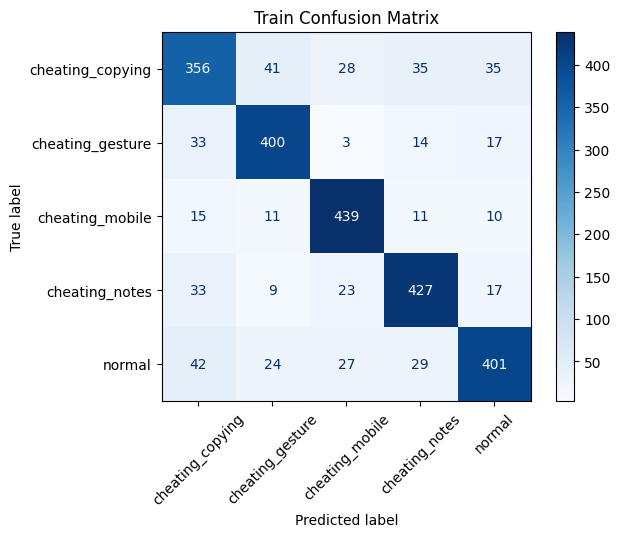


VALIDATION RESULTS
Loss      : 1.1639
Accuracy  : 0.6419
Precision : 0.6679
Recall    : 0.6419
F1 Score  : 0.6409

Classification Report:

                  precision    recall  f1-score   support

cheating_copying     0.5556    0.6832    0.6128       161
cheating_gesture     0.4714    0.5156    0.4925        64
 cheating_mobile     0.7259    0.8596    0.7871       114
  cheating_notes     0.5938    0.6477    0.6196        88
          normal     0.8264    0.5181    0.6369       193

        accuracy                         0.6419       620
       macro avg     0.6346    0.6449    0.6298       620
    weighted avg     0.6679    0.6419    0.6409       620



<Figure size 800x800 with 0 Axes>

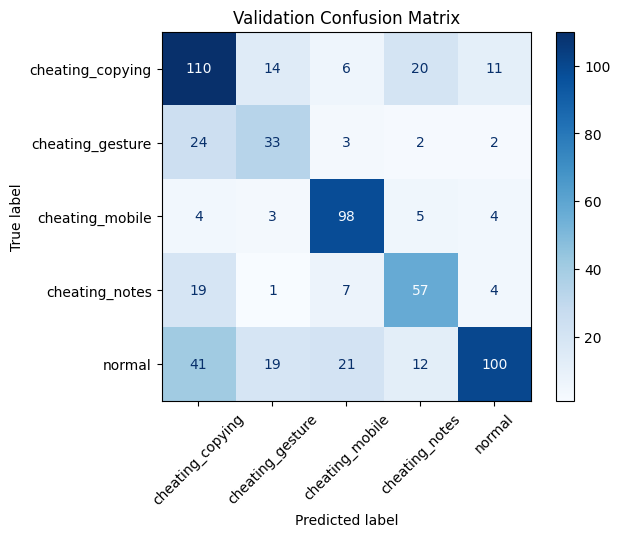

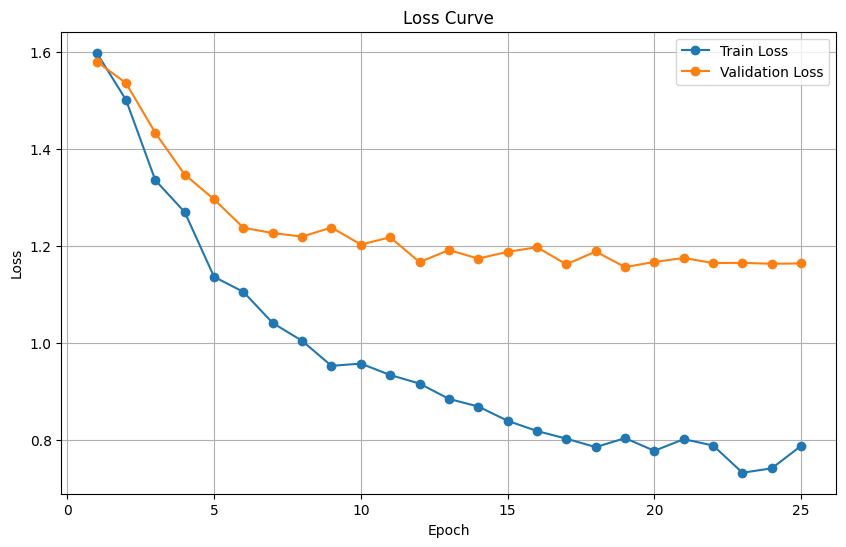

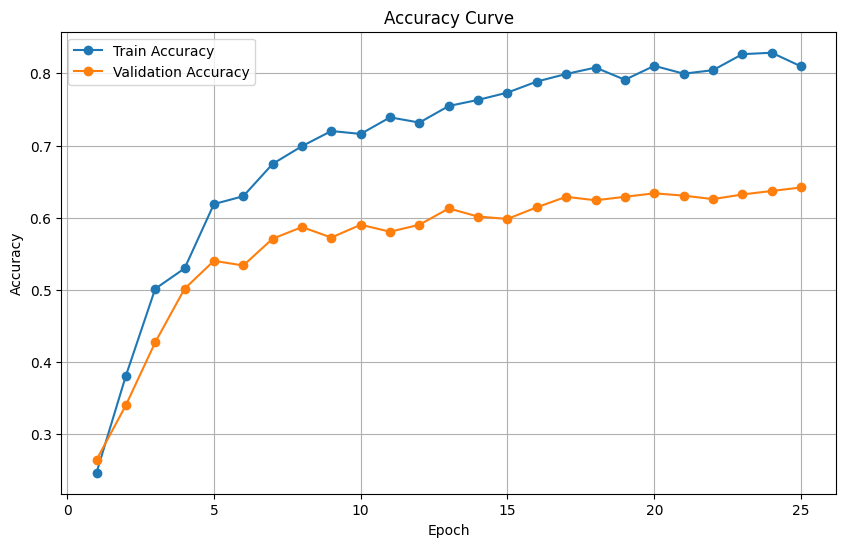

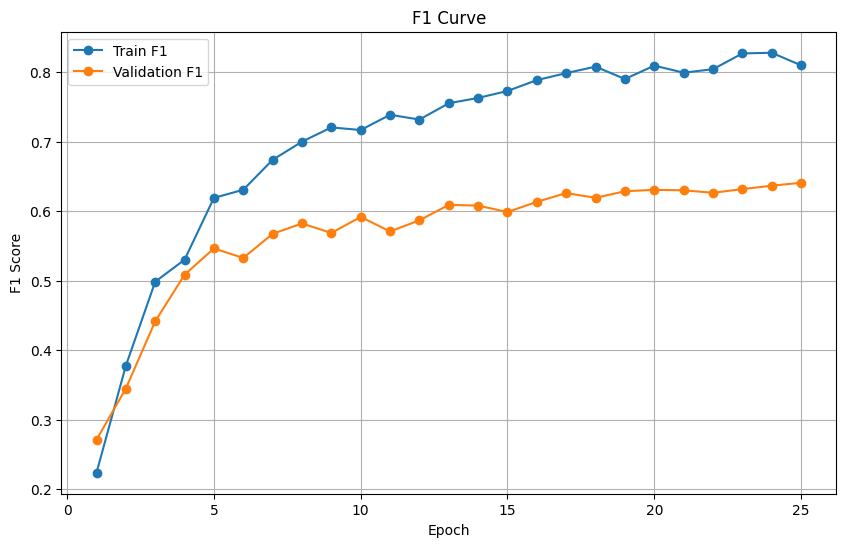


FINAL SUMMARY
      Dataset      Loss  Accuracy  Precision    Recall  F1 Score
0       Train  0.766934  0.815726   0.815110  0.815726  0.814808
1  Validation  1.163855  0.641935   0.667944  0.641935  0.640923

All files saved successfully
/kaggle/working/


In [5]:
# =========================================================
# FINAL EVALUATION
# =========================================================

model.load_state_dict(
    torch.load(
        "/kaggle/working/best_videomae.pth"
    )
)

# =========================================================
# EVALUATION FUNCTION
# =========================================================

def evaluate_model(loader, set_name="Validation"):

    model.eval()

    all_preds = []
    all_labels = []

    total_loss = 0

    with torch.no_grad():

        for pixel_values, labels in loader:

            pixel_values = pixel_values.to(device)
            labels = labels.to(device)

            outputs = model(
                pixel_values=pixel_values
            )

            logits = outputs.logits

            loss = criterion(
                logits,
                labels
            )

            total_loss += loss.item()

            preds = torch.argmax(
                logits,
                dim=1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    avg_loss = total_loss / len(loader)

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average='weighted',
        zero_division=0
    )

    print(f"\n{'='*60}")
    print(f"{set_name.upper()} RESULTS")
    print(f"{'='*60}")

    print(f"Loss      : {avg_loss:.4f}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report:\n")

    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )

    print(report)

    cm = confusion_matrix(
        all_labels,
        all_preds
    )

    plt.figure(figsize=(8,8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        cmap="Blues",
        xticks_rotation=45
    )

    plt.title(f"{set_name} Confusion Matrix")

    plt.show()

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "preds": all_preds,
        "labels": all_labels
    }

# =========================================================
# EVALUATION
# =========================================================

train_results = evaluate_model(
    train_loader,
    "Train"
)

val_results = evaluate_model(
    val_loader,
    "Validation"
)

# =========================================================
# LOSS CURVE
# =========================================================

epochs_range = range(
    1,
    len(train_losses)+1
)

plt.figure(figsize=(10,6))

plt.plot(
    epochs_range,
    train_losses,
    marker='o',
    label="Train Loss"
)

plt.plot(
    epochs_range,
    val_losses,
    marker='o',
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)

plt.show()

# =========================================================
# ACCURACY CURVE
# =========================================================

plt.figure(figsize=(10,6))

plt.plot(
    epochs_range,
    train_accs,
    marker='o',
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    val_accs,
    marker='o',
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)

plt.show()

# =========================================================
# F1 CURVE
# =========================================================

plt.figure(figsize=(10,6))

plt.plot(
    epochs_range,
    train_f1s,
    marker='o',
    label="Train F1"
)

plt.plot(
    epochs_range,
    val_f1s,
    marker='o',
    label="Validation F1"
)

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("F1 Curve")
plt.legend()
plt.grid(True)

plt.show()

# =========================================================
# FINAL SUMMARY
# =========================================================

summary_df = pd.DataFrame({

    "Dataset": ["Train", "Validation"],

    "Loss": [
        train_results["loss"],
        val_results["loss"]
    ],

    "Accuracy": [
        train_results["accuracy"],
        val_results["accuracy"]
    ],

    "Precision": [
        train_results["precision"],
        val_results["precision"]
    ],

    "Recall": [
        train_results["recall"],
        val_results["recall"]
    ],

    "F1 Score": [
        train_results["f1"],
        val_results["f1"]
    ]
})

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print(summary_df)

summary_df.to_csv(
    "/kaggle/working/VideoMAE_Final_Summary.csv",
    index=False
)

# =========================================================
# SAVE FINAL MODEL
# =========================================================

torch.save(
    model.state_dict(),
    "/kaggle/working/final_videomae_model.pth"
)

print("\nAll files saved successfully")
print("/kaggle/working/")

In [27]:
# =========================================================
# SAVE ALL RESULTS + GRAPHS + MATRICES + MODEL IN ZIP
# =========================================================

import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# =========================================================
# CREATE OUTPUT DIRECTORY
# =========================================================

SAVE_DIR = "/kaggle/working/VideoMAE_Results"

os.makedirs(SAVE_DIR, exist_ok=True)

# =========================================================
# SAVE CONFUSION MATRIX FUNCTION
# =========================================================

def save_confusion_matrix(labels, preds, set_name):

    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(8,8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        cmap="Blues",
        xticks_rotation=45
    )

    plt.title(f"{set_name} Confusion Matrix")

    save_path = os.path.join(
        SAVE_DIR,
        f"{set_name}_confusion_matrix.png"
    )

    plt.savefig(
        save_path,
        bbox_inches="tight"
    )

    plt.close()

# =========================================================
# SAVE CLASSIFICATION REPORT
# =========================================================

train_report = classification_report(
    train_results["labels"],
    train_results["preds"],
    target_names=class_names,
    digits=4
)

val_report = classification_report(
    val_results["labels"],
    val_results["preds"],
    target_names=class_names,
    digits=4
)

with open(
    os.path.join(SAVE_DIR, "Train_Classification_Report.txt"),
    "w"
) as f:

    f.write(train_report)

with open(
    os.path.join(SAVE_DIR, "Validation_Classification_Report.txt"),
    "w"
) as f:

    f.write(val_report)

# =========================================================
# SAVE CONFUSION MATRICES
# =========================================================

save_confusion_matrix(
    train_results["labels"],
    train_results["preds"],
    "Train"
)

save_confusion_matrix(
    val_results["labels"],
    val_results["preds"],
    "Validation"
)

# =========================================================
# SAVE LOSS CURVE
# =========================================================

epochs_range = range(
    1,
    len(train_losses)+1
)

plt.figure(figsize=(10,6))

plt.plot(
    epochs_range,
    train_losses,
    marker='o',
    label="Train Loss"
)

plt.plot(
    epochs_range,
    val_losses,
    marker='o',
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(SAVE_DIR, "Loss_Curve.png"),
    bbox_inches="tight"
)

plt.close()

# =========================================================
# SAVE ACCURACY CURVE
# =========================================================

plt.figure(figsize=(10,6))

plt.plot(
    epochs_range,
    train_accs,
    marker='o',
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    val_accs,
    marker='o',
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(SAVE_DIR, "Accuracy_Curve.png"),
    bbox_inches="tight"
)

plt.close()

# =========================================================
# SAVE F1 CURVE
# =========================================================

plt.figure(figsize=(10,6))

plt.plot(
    epochs_range,
    train_f1s,
    marker='o',
    label="Train F1"
)

plt.plot(
    epochs_range,
    val_f1s,
    marker='o',
    label="Validation F1"
)

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("F1 Curve")

plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(SAVE_DIR, "F1_Curve.png"),
    bbox_inches="tight"
)

plt.close()

# =========================================================
# SAVE FINAL SUMMARY CSV
# =========================================================

summary_df = pd.DataFrame({

    "Dataset": ["Train", "Validation"],

    "Loss": [
        train_results["loss"],
        val_results["loss"]
    ],

    "Accuracy": [
        train_results["accuracy"],
        val_results["accuracy"]
    ],

    "Precision": [
        train_results["precision"],
        val_results["precision"]
    ],

    "Recall": [
        train_results["recall"],
        val_results["recall"]
    ],

    "F1 Score": [
        train_results["f1"],
        val_results["f1"]
    ]
})

summary_csv_path = os.path.join(
    SAVE_DIR,
    "VideoMAE_Final_Summary.csv"
)

summary_df.to_csv(
    summary_csv_path,
    index=False
)

# =========================================================
# SAVE MODEL
# =========================================================

model_save_path = os.path.join(
    SAVE_DIR,
    "best_videomae.pth"
)

torch.save(
    model.state_dict(),
    model_save_path
)

# =========================================================
# CREATE ZIP FILE
# =========================================================

zip_path = "/kaggle/working/VideoMAE_Results.zip"

with zipfile.ZipFile(
    zip_path,
    'w',
    zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, files in os.walk(SAVE_DIR):

        for file in files:

            file_path = os.path.join(root, file)

            zipf.write(
                file_path,
                arcname=os.path.relpath(
                    file_path,
                    SAVE_DIR
                )
            )

# =========================================================
# FINAL MESSAGE
# =========================================================

print("="*60)
print("ALL FILES SAVED SUCCESSFULLY")
print("="*60)

print("\nSaved Folder:")
print(SAVE_DIR)

print("\nZIP File:")
print(zip_path)

print("\nFiles Included:")
print("- Confusion Matrices")
print("- Classification Reports")
print("- Loss Curve")
print("- Accuracy Curve")
print("- F1 Curve")
print("- Final Summary CSV")
print("- Best Model (.pth)")

# =========================================================
# DOWNLOAD LINK
# =========================================================

from IPython.display import FileLink

FileLink(zip_path)

ALL FILES SAVED SUCCESSFULLY

Saved Folder:
/kaggle/working/VideoMAE_Results

ZIP File:
/kaggle/working/VideoMAE_Results.zip

Files Included:
- Confusion Matrices
- Classification Reports
- Loss Curve
- Accuracy Curve
- F1 Curve
- Final Summary CSV
- Best Model (.pth)


/kaggle/working/VideoMAE_Results.zip

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>